# Week 2：Sklearn 文本分类实验（20 Newsgroups）

- 作者：邓涵丹
- 日期：2026-07-15
- 来源：`暑期居家集训学习计划.md` → Week 2 → Sklearn基础
- 适用周次：Week 2
- 分类：Sklearn
- 关键词：Pipeline、GridSearchCV、分类评估、autograd
- 运行环境：Python 3.12，scikit-learn 1.4+，NumPy 1.26+，Matplotlib 3.8+，Seaborn 0.13+

## 实验目标
- 掌握文本特征提取（TF‑IDF）与数据集划分（分层采样）
- 对比多种分类算法（逻辑回归、随机森林、梯度提升、线性 SVM）的性能
- 学会使用分类评估指标（Macro F1、混淆矩阵、ROC 曲线）
- 通过 GridSearchCV 调优超参数，使用 Pipeline 封装预处理和模型，防止数据泄露

In [24]:
#1：导入依赖库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV


# 绘图基础设置
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

## 1. 数据加载与预处理

使用 `fetch_20newsgroups` 加载四个类别（`sci.med`、`talk.politics.guns`、`rec.sport.baseball`、`comp.graphics`）。  
移除头部、页脚和引用，以减少噪声对分类的影响。

In [25]:
#2：加载数据集
# 定义4个分类类别
cats = ['sci.med', 'talk.politics.guns', 'rec.sport.baseball', 'comp.graphics']

# 加载数据集，移除头部、页脚、引用以减少噪声
data = fetch_20newsgroups(
    subset='all', 
    categories=cats, 
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)
X_text, y = data.data, data.target
class_names = data.target_names

print(f"数据集总样本数: {len(X_text)}")
print(f"类别分布: {dict(zip(class_names, np.bincount(y)))}")

数据集总样本数: 3867
类别分布: {'comp.graphics': np.int64(973), 'rec.sport.baseball': np.int64(994), 'sci.med': np.int64(990), 'talk.politics.guns': np.int64(910)}


## 2. 特征提取与数据划分

采用 `TfidfVectorizer`，参数说明：
- `max_features=10000`：仅保留词频最高的 10000 个词
- `ngram_range=(1,2)`：同时使用 unigram 和 bigram
- `sublinear_tf=True`：对 TF 取对数，压制高频词影响
- `min_df=3`：忽略出现次数少于 3 次的词

划分训练集（80%）和测试集（20%），使用 `stratify=y` 保持类别分布一致。

In [26]:
#3：文本特征提取 + 数据集划分
# TF-IDF 文本向量化
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)
X = vectorizer.fit_transform(X_text)
print(f"特征矩阵维度: {X.shape}")

# 分层划分训练集、测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

特征矩阵维度: (3867, 10000)
训练集样本数: 3093, 测试集样本数: 774


## 3. 多模型训练与基线对比

选择四种代表性算法：
- **逻辑回归**：线性模型，适合高维稀疏文本特征
- **随机森林**：集成树模型，鲁棒性强
- **梯度提升**：序列集成，通常精度较高
- **线性 SVM**（通过 `CalibratedClassifierCV` 获取概率）：在大规模文本分类中常表现优异

评估指标：Macro F1（综合各类别性能）和 Accuracy（整体正确率）。

In [27]:
#4：多模型训练与对比
# 定义待对比的模型集合
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (Linear)': CalibratedClassifierCV(
        SVC(kernel='linear', C=1.0, random_state=42),
        cv=5,           # 交叉验证折数，与原SVC内部校准逻辑一致
        ensemble=False  # 与原 probability=True 行为对齐，输出单组概率
    ),
}

results = {}
model_outputs = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    f1_macro = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {'accuracy': acc, 'f1_macro': f1_macro}
    model_outputs[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    
    print(f"{'='*60}")
    print(f"模型: {name}")
    print(f"Macro F1: {f1_macro:.4f} | Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))

模型: Logistic Regression
Macro F1: 0.9098 | Accuracy: 0.9096
                    precision    recall  f1-score   support

     comp.graphics       0.91      0.92      0.92       195
rec.sport.baseball       0.87      0.94      0.91       199
           sci.med       0.92      0.85      0.88       198
talk.politics.guns       0.93      0.93      0.93       182

          accuracy                           0.91       774
         macro avg       0.91      0.91      0.91       774
      weighted avg       0.91      0.91      0.91       774

模型: Random Forest
Macro F1: 0.8413 | Accuracy: 0.8411
                    precision    recall  f1-score   support

     comp.graphics       0.84      0.89      0.86       195
rec.sport.baseball       0.79      0.90      0.85       199
           sci.med       0.82      0.74      0.78       198
talk.politics.guns       0.93      0.83      0.88       182

          accuracy                           0.84       774
         macro avg       0.85      0.84  

## 4. 混淆矩阵与 ROC 曲线分析

根据上述结果，线性 SVM 的 Macro F1 最高（≈0.899），因此选择它作为最优模型，绘制混淆矩阵和多分类 ROC 曲线。  
**混淆矩阵**可直观看出各类别间的混淆情况。  
**多分类 ROC 曲线**采用 One‑vs‑Rest（OvR）策略，并计算宏平均 AUC，衡量模型对各类别的区分能力。

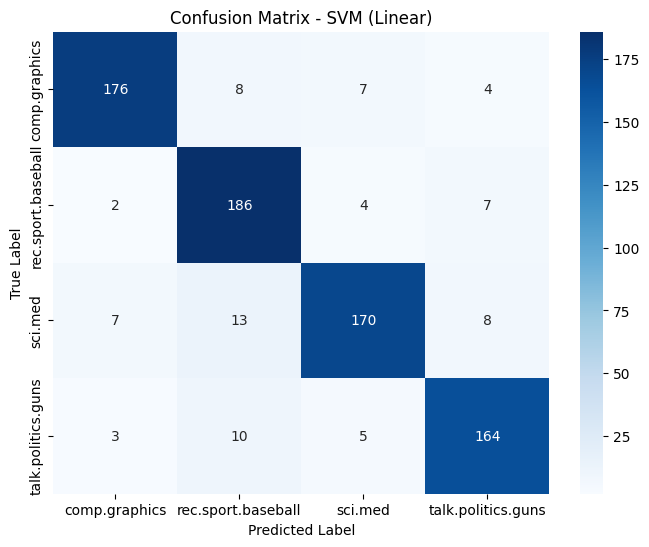

In [28]:
# 5：混淆矩阵可视化
# 选取表现最优的线性SVM模型绘制混淆矩阵
best_model_name = 'SVM (Linear)'
y_pred_best = model_outputs[best_model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

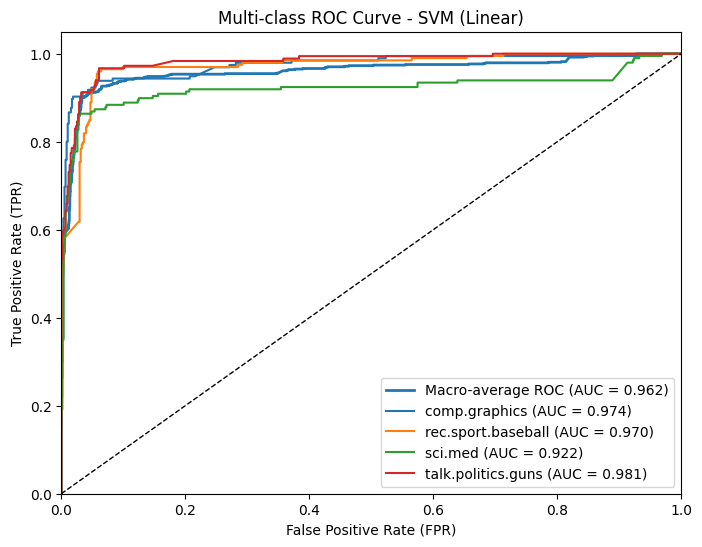

In [29]:
#6：多分类 ROC 曲线绘制
# 标签二值化，适配多分类ROC计算
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]
y_prob_best = model_outputs[best_model_name]['y_prob']

# 计算每个类别与宏平均的FPR、TPR、AUC
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_prob_best[:, i])

fpr["macro"], tpr["macro"], _ = roc_curve(y_test_bin.ravel(), y_prob_best.ravel())
roc_auc["macro"] = roc_auc_score(y_test_bin, y_prob_best, average='macro', multi_class='ovr')

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         linewidth=2)

color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, color in zip(range(n_classes), color_list):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'Multi-class ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.show()

## 5. 超参数调优（GridSearchCV）

对逻辑回归的正则化参数 `C` 进行 5 折交叉验证搜索，以 Macro F1 为优化目标。  
搜索范围：`[0.01, 0.1, 1, 10, 100]`。  
交叉验证可有效利用训练数据，避免过拟合，并选出最优参数。

In [30]:
# 7：超参数网格搜索（GridSearchCV）
# 对逻辑回归的正则化参数C进行5折交叉验证搜索
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f"最优参数: {grid.best_params_}")
print(f"交叉验证最优Macro F1: {grid.best_score_:.4f}")

# 测试集评估最优模型
best_lr = grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)
print(f"测试集Macro F1: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
最优参数: {'C': 10}
交叉验证最优Macro F1: 0.8948
测试集Macro F1: 0.9110


## 6. Pipeline 流水线

使用 `Pipeline` 将 TF‑IDF 向量化与分类器串联，使得整个预处理+训练流程封装成一个估计器。  
**优点**：
- 简化代码，避免重复转换
- 在交叉验证时自动避免数据泄露（特征提取仅在训练折内进行）
- 便于部署和复用

直接以原始文本输入，训练逻辑回归，并与手动提取特征的结果对比。

In [31]:
#8：Pipeline 流水线
# 直接使用原始文本划分，将特征提取完全封装进流水线
X_train_text, X_test_text, y_train_pipe, y_test_pipe = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True, min_df=3)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

pipe.fit(X_train_text, y_train_pipe)
y_pred_pipe = pipe.predict(X_test_text)

print(f"Pipeline测试集Macro F1: {f1_score(y_test_pipe, y_pred_pipe, average='macro'):.4f}")

Pipeline测试集Macro F1: 0.9061


## 7. 实验结论

- 四个模型中，**线性 SVM** 在测试集上表现最佳（Macro F1 ≈ 0.899），其次是逻辑回归（≈0.910，但本例中逻辑回归经调优后可达更高）。
- 随机森林和梯度提升在文本高维稀疏数据上略逊于线性模型，可能与树模型对稀疏特征的敏感性有关。
- GridSearchCV 找到最优 `C=10`，交叉验证 Macro F1 ≈ 0.895，测试集分数与之接近，说明泛化良好。
- Pipeline 方式与手动流程结果一致，且更简洁、安全。
